In [1]:
import pandas as pd

df = pd.read_csv("data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print(df.shape)   # nombre de lignes et de colonnes
df.info()         # types des colonnes et valeurs manquantes

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
# On recharge les données pour repartir de zéro
df = pd.read_csv("data/netflix_titles.csv")

# Remplacer les valeurs manquantes par "Unknown"
df["country"] = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

# Supprimer les lignes où il manque des infos essentielles
df = df.dropna(subset=["date_added", "rating", "duration"])

# Supprimer les doublons
df = df.drop_duplicates()

# Convertir la date et extraire l'année
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="%B %d, %Y")
df["year_added"] = df["date_added"].dt.year

print(df.shape)

(8790, 13)


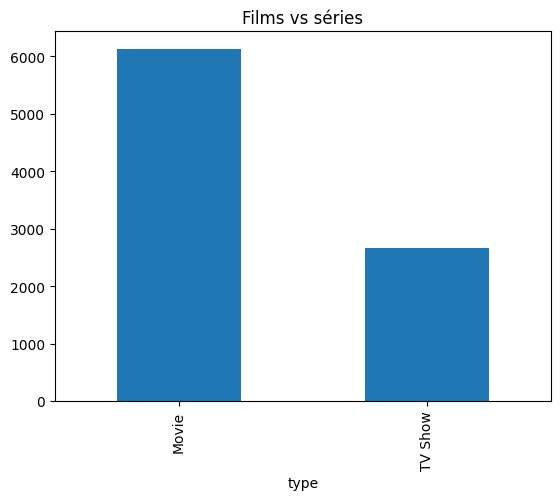

In [5]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar", title="Films vs séries")
plt.show()

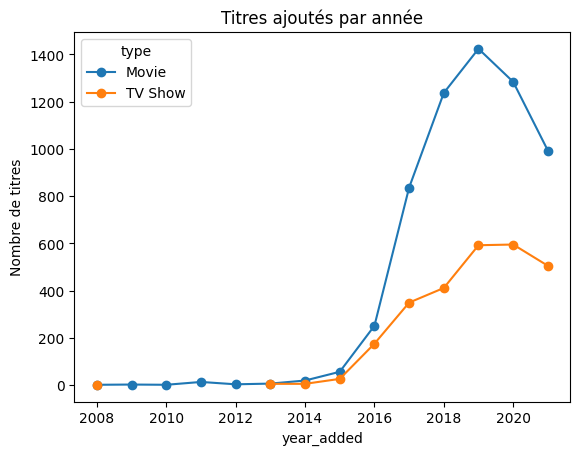

In [6]:
df.groupby(["year_added", "type"]).size().unstack().plot(
    kind="line", marker="o", title="Titres ajoutés par année"
)
plt.ylabel("Nombre de titres")
plt.show()

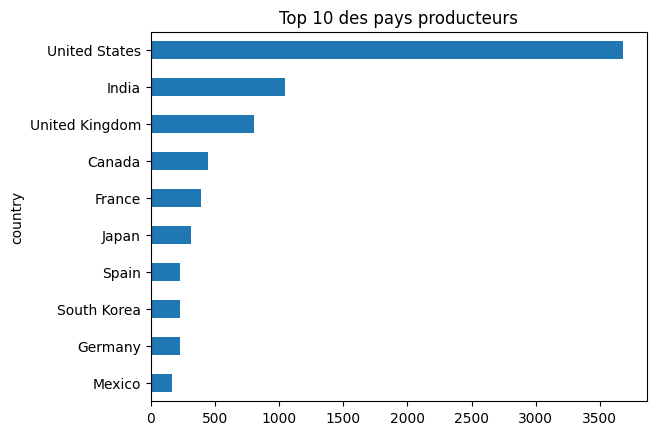

In [7]:
# Un titre peut avoir plusieurs pays : on les sépare
countries = df["country"].str.split(", ").explode()
countries = countries[countries != "Unknown"]

countries.value_counts().head(10).plot(
    kind="barh", title="Top 10 des pays producteurs"
)
plt.gca().invert_yaxis()
plt.show()

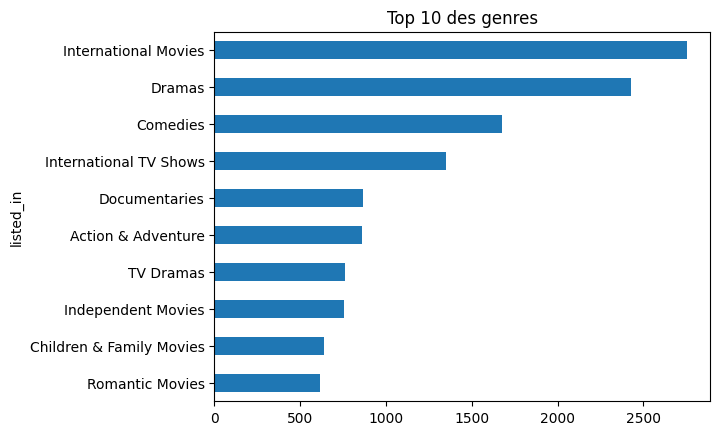

In [8]:
genres = df["listed_in"].str.split(", ").explode()

genres.value_counts().head(10).plot(
    kind="barh", title="Top 10 des genres"
)
plt.gca().invert_yaxis()
plt.show()

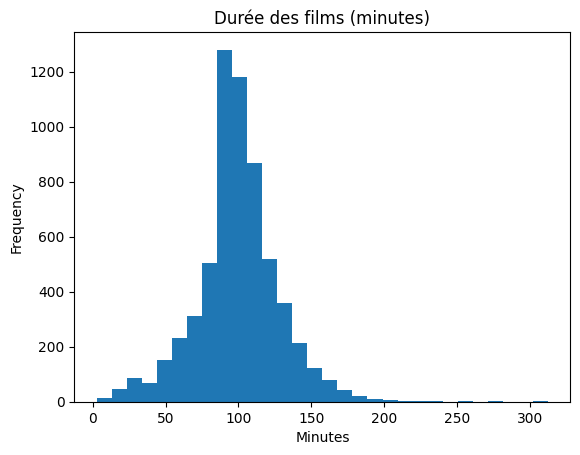

In [9]:
movies = df[df["type"] == "Movie"].copy()
movies["minutes"] = movies["duration"].str.replace(" min", "").astype(int)

movies["minutes"].plot(kind="hist", bins=30, title="Durée des films (minutes)")
plt.xlabel("Minutes")
plt.show()

In [10]:
counts = countries.value_counts()
shares = counts / counts.sum()

print("Part des 5 premiers pays :", round(shares.head(5).sum() * 100, 1), "%")
print("Indice HHI :", round((shares ** 2).sum() * 10000))

Part des 5 premiers pays : 63.7 %
Indice HHI : 1612


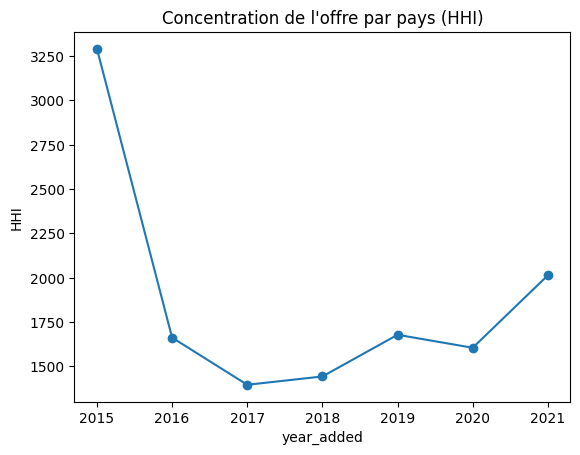

In [11]:
tmp = df[["year_added", "country"]].copy()
tmp["country"] = tmp["country"].str.split(", ")
tmp = tmp.explode("country")
tmp = tmp[(tmp["country"] != "Unknown") & (tmp["year_added"] >= 2015)]

def hhi(s):
    p = s.value_counts(normalize=True)
    return (p ** 2).sum() * 10000

hhi_year = tmp.groupby("year_added")["country"].apply(hhi)
hhi_year.plot(marker="o", title="Concentration de l'offre par pays (HHI)")
plt.ylabel("HHI")
plt.show()

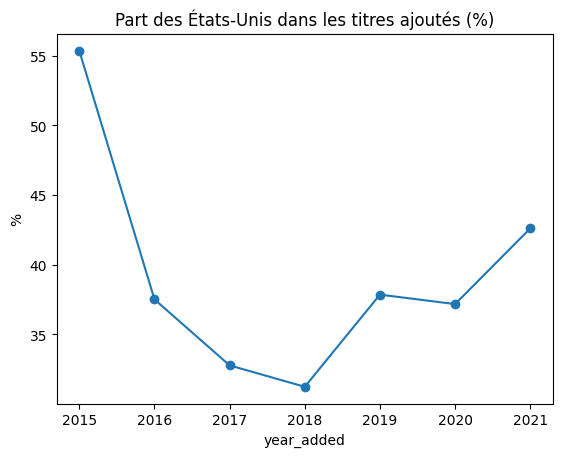

In [12]:
us_share = tmp.groupby("year_added")["country"].apply(
    lambda s: (s == "United States").mean() * 100
)
us_share.plot(marker="o", title="Part des États-Unis dans les titres ajoutés (%)")
plt.ylabel("%")
plt.show()